# **Proyecto Integrador**
## **Baseline**

Montserrat Gaytán Morales - A01332220

Alberto Eduardo De Zamacona Garza - A00590592

Ernesto Ignacio Borbón Martínez - A01701515

## Librerias

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
import pydot
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Base de datos

In [ ]:
X_test_scaled = pd.read_csv('X_test_scaled.csv')
X_test_scaled = X_test_scaled[X_test_scaled.columns[1:]]
X_train_scaled = pd.read_csv('X_train_scaled.csv')
X_train_scaled = X_train_scaled[X_train_scaled.columns[1:]]
y_test = pd.read_csv('y_test.csv')
y_test = y_test[y_test.columns[1:]]
y_train = pd.read_csv('y_train.csv')
y_train = y_train[y_train.columns[1:]]

## **1. ¿Qué algoritmo baseline?**

Para verificar la funcionalidad de un modelo de ML en este problema, se seleccionó *RandomForestClassifier* como modelo baseline robusto inicial, debido a que el problema corresponde a una tarea de clasificación. Se espera que existan relaciones no lineales e interacciones complejas entre factores como costos, perfil del cliente, complejidad técnica, presión de preventa y estrategia comercial, las cuales pueden influir conjuntamente en la aceptación de una propuesta y su rentabilidad.

Además, Random Forest resulta adecuado para conjuntos de datos de tamaño moderado (~1,500 registros), presenta robustez ante ruido y multicolinealidad, y reduce el riesgo de sobreajuste al combinar múltiples árboles entrenados sobre subconjuntos aleatorios de datos y variables.

Adicionalmente, el modelo permite analizar la importancia de variables, aspecto relevante para entender qué factores influyen en la toma de decisiones comerciales y financieras.

Para complementar la evaluación, se utiliza posteriormente un *DummyClassifier* como referencia de comparación. Este modelo permite contrastar el desempeño del Random Forest contra un comportamiento cercano al azar y verificar si las variables disponibles contienen señal predictiva útil para el problema de negocio.

In [ ]:
# Random Forest Classifier
clf = RandomForestClassifier(max_depth=len(X_test_scaled.columns)//2, # max_depth la mitad de las variables de la base de datos
                             min_samples_split = 5, # no dividir si se tiene menos de 5 registros
                             random_state=0)

In [ ]:
clf.fit(X_train_scaled,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=4, min_samples_split=5, random_state=0)

In [ ]:
ytrain_pred = clf.predict(X_train_scaled)
ytest_pred = clf.predict(X_test_scaled)

In [ ]:
def metrics(ytrue, ypred):
  cm = confusion_matrix(ytrue, ypred)
  sns.heatmap(cm, annot=True, fmt='d',cbar=False)
  plt.title('Confusion matrix')
  plt.ylabel('Actual label')
  plt.xlabel('Predicted label')
  plt.show()
  print(classification_report(ytrue, ypred))

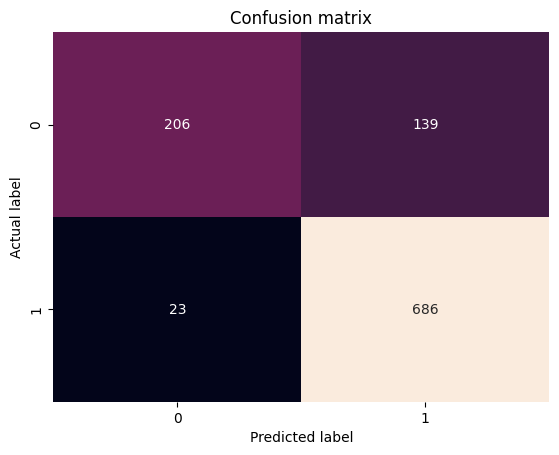

              precision    recall  f1-score   support

           0       0.90      0.60      0.72       345
           1       0.83      0.97      0.89       709

    accuracy                           0.85      1054
   macro avg       0.87      0.78      0.81      1054
weighted avg       0.85      0.85      0.84      1054



In [ ]:
# Conjunto de entrenamiento
metrics(y_train, ytrain_pred)

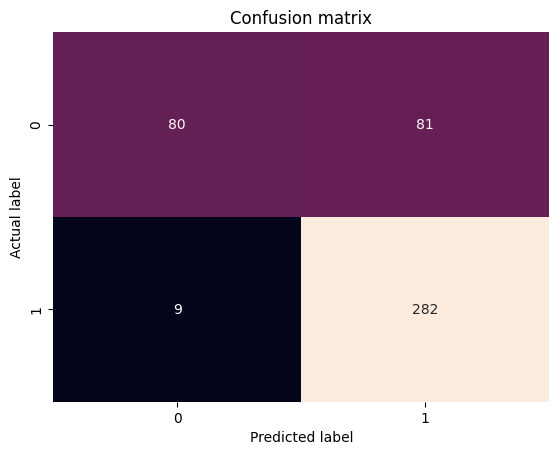

              precision    recall  f1-score   support

           0       0.90      0.50      0.64       161
           1       0.78      0.97      0.86       291

    accuracy                           0.80       452
   macro avg       0.84      0.73      0.75       452
weighted avg       0.82      0.80      0.78       452



In [ ]:
# Conjunto de prueba
metrics(y_test, ytest_pred)

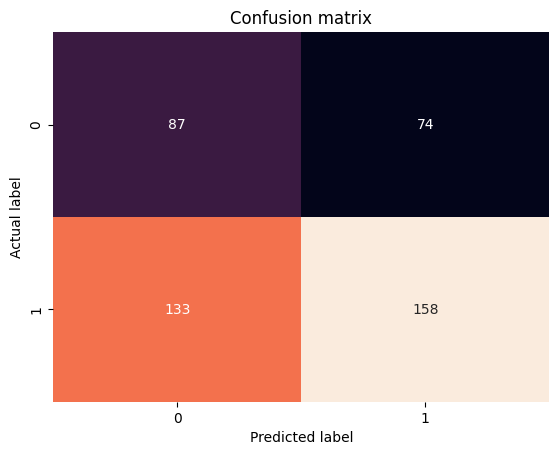

              precision    recall  f1-score   support

           0       0.40      0.54      0.46       161
           1       0.68      0.54      0.60       291

    accuracy                           0.54       452
   macro avg       0.54      0.54      0.53       452
weighted avg       0.58      0.54      0.55       452



In [ ]:
# clasificador dummy
dummy = DummyClassifier(strategy='uniform')
dummy.fit(X_train_scaled, y_train)
ytest_pred_dummy = dummy.predict(X_test_scaled)
metrics(y_test, ytest_pred_dummy)

La comparación muestra que el *RandomForestClassifier* presenta un desempeño significativamente superior al modelo dummy, lo que indica que el conjunto de datos contiene información útil para la predicción. En el conjunto de prueba, el modelo alcanzó una accuracy de 0.80, frente a 0.54 del baseline aleatorio, además de un F1-score ponderado de 0.78 contra 0.55. Esto refleja un mejor equilibrio general entre precisión y recall.

Asimismo, el modelo logró un desempeño sólido en la identificación de la clase positiva, con un recall de 0.97. Esto sugiere una alta sensibilidad para detectar propuestas positivas. Sin embargo, este resultado debe interpretarse junto con el desempeño de la clase negativa, ya que el modelo tiende a favorecer la predicción positiva. En términos de negocio, esto puede ser aceptable si el modelo se usa como herramienta de priorización, pero no como mecanismo automático de decisión.

Aunque existe una diferencia cercana al 5% entre entrenamiento y prueba, lo que indica un ligero sobreajuste, el rendimiento en datos no vistos se mantiene estable y claramente superior al azar.

En conclusión, los resultados respaldan la viabilidad del problema predictivo y la relevancia de las variables seleccionadas. No obstante, futuras iteraciones deberán revisar el balance entre recall y precisión para evitar una clasificación excesivamente permisiva de oportunidades comerciales.

## **2. ¿Características importantes?**

In [ ]:
# Extraer un árbol de decisión individual del Random Forest
individual_tree = clf.estimators_[0]  # Obtener el primer árbol

# Exportar el árbol de decisión a un archivo DOT
export_graphviz(individual_tree, out_file='individual_tree.dot',
                feature_names=X_train_scaled.columns.to_list(),
                class_names=['rechazo','aprovado'],
                rounded=True, filled=True)

# Convertir el archivo DOT a una imagen PNG usando Graphviz
(graph,) = pydot.graph_from_dot_file('individual_tree.dot')

# Guardar la imagen PNG
graph.write_png('individual_tree.png')

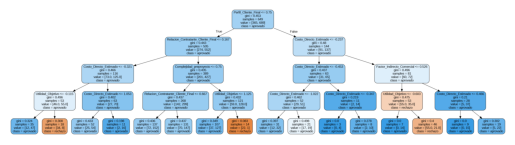

In [ ]:
def show_with_matplotlib(path: str) -> None:
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg

    img = mpimg.imread(path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
show_with_matplotlib('/content/individual_tree.png')

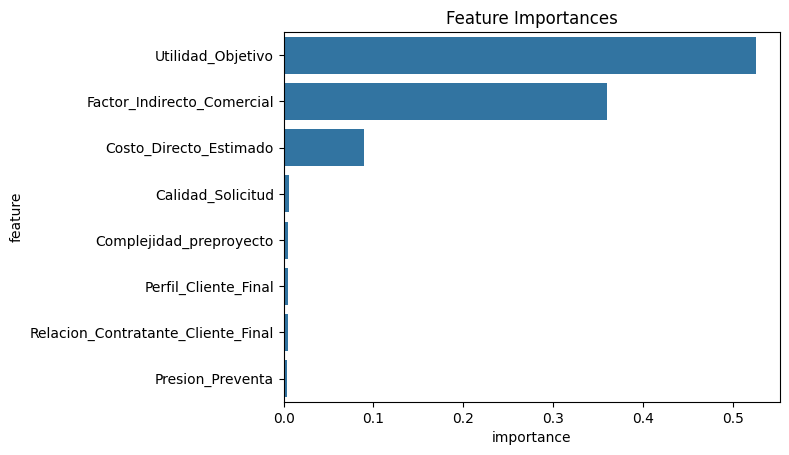

In [ ]:
importances = clf.feature_importances_
df_feature_importances = pd.DataFrame({'feature': X_train_scaled.columns, 'importance': importances})
df_feature_importances.sort_values(by='importance', ascending=False, inplace=True)
sns.barplot(x='importance', y='feature', data=df_feature_importances)
plt.title('Feature Importances')
plt.show()

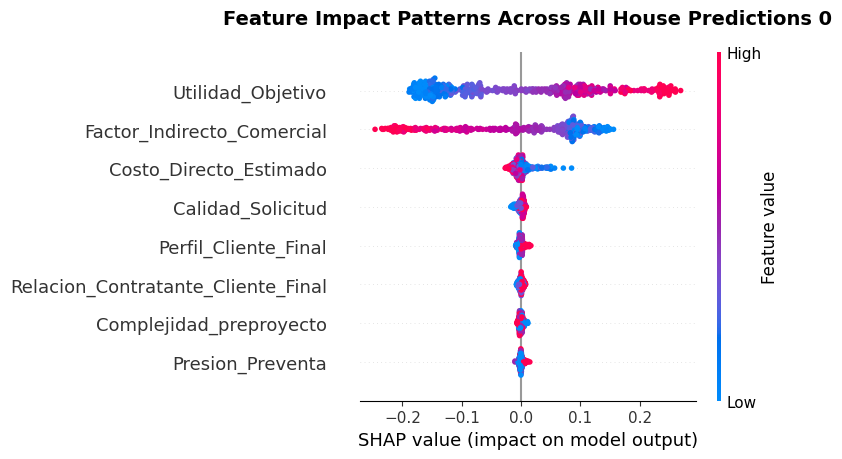

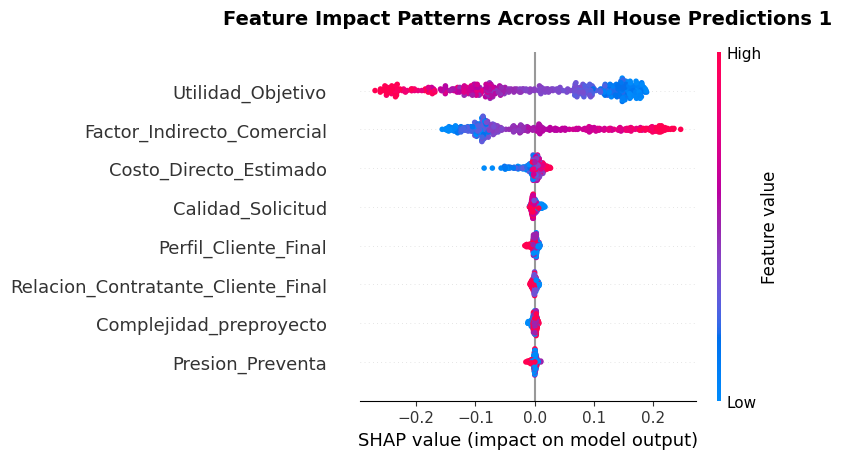

In [ ]:
# Importar la librería SHAP
import shap

# Iniciar explicador SHAP para el modelo entrenado
explainer = shap.TreeExplainer(clf)

# Calcular los valores SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test_scaled)

# Generar gráficos de resumen SHAP para cada clase
for i in [0,1]:
  plt.figure(figsize=(12, 10))
  shap.summary_plot(
      shap_values[:, :, i],
      X_test_scaled,
      feature_names=X_test_scaled.columns.tolist(),
      # max_display=20,  # Mostrar las 20 variables más importantes
      show=False
  )
  plt.title(f'Feature Impact Patterns Across All House Predictions {iS}',
            fontsize=14, fontweight='bold', pad=20)
  plt.tight_layout()
  plt.show()

El análisis de importancia de características muestra que *Utilidad_Objetivo* y *Factor_Indirecto_Comercial* son las variables con mayor influencia en la predicción del modelo, seguidas a mayor distancia por *Costo_Directo_Estimado*. Tanto el ranking de importancia como el análisis SHAP sugieren que, para este conjunto de datos, el modelo está utilizando principalmente variables económicas asociadas al margen y a la estrategia de precio. En contraste, los factores asociados a la operación y a la relación comercial presentan un impacto menor dentro del modelo evaluado.

Adicionalmente, se propone evaluar en futuras iteraciones el reemplazo o ajuste de la variable *Factor_Indirecto_Comercial* por *Prima_Cliente*, con el fin de analizar posibles cambios en el desempeño del modelo, interpretabilidad e importancia de características. Esta prueba permitiría observar si el componente comercial asociado al cliente aporta información predictiva adicional o más clara que el factor indirecto comercial agregado.

##**3. ¿Sub/sobreajuste?**

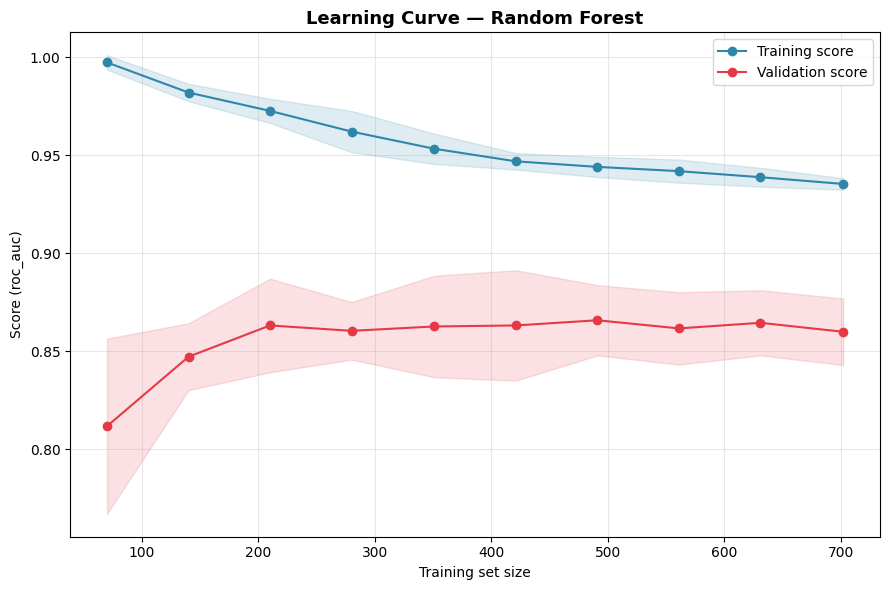

(array([ 70, 140, 210, 280, 351, 421, 491, 561, 631, 702]),
 array([[1.        , 0.99224806, 1.        ],
        [0.97869318, 0.97911283, 0.98830409],
        [0.96425872, 0.97469388, 0.97903176],
        [0.94863342, 0.96324561, 0.97441205],
        [0.94416964, 0.95264421, 0.96316739],
        [0.94319869, 0.94474529, 0.9527972 ],
        [0.937768  , 0.94402587, 0.95043203],
        [0.93454082, 0.94214374, 0.94901138],
        [0.93387783, 0.937227  , 0.94531376],
        [0.9314066 , 0.93851326, 0.93616884]]),
 array([[0.85173363, 0.74926308, 0.833972  ],
        [0.87119795, 0.83730656, 0.83292189],
        [0.88838745, 0.83102432, 0.86991525],
        [0.87594937, 0.84064112, 0.86451732],
        [0.89029536, 0.82792926, 0.86952837],
        [0.88871767, 0.82385777, 0.87676861],
        [0.88717666, 0.84325718, 0.86685704],
        [0.88119611, 0.83684598, 0.86678335],
        [0.88440653, 0.84368091, 0.86529108],
        [0.88385617, 0.84638909, 0.84941046]]))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold


def plot_learning_curve(
    estimator,
    X,
    y,
    title="Learning Curve",
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42,
):
    """
    Plot a learning curve for a classification model.

    Parameters
    ----------
    estimator : sklearn-compatible model
    X, y : features and target
    scoring : 'roc_auc', 'f1', 'accuracy', 'average_precision', etc.
    """
    cv_splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv_splitter,
        scoring=scoring,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=random_state,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(train_sizes_abs, train_mean, "o-", color="#2E86AB", label="Training score")
    ax.fill_between(
        train_sizes_abs,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15,
        color="#2E86AB",
    )

    ax.plot(train_sizes_abs, val_mean, "o-", color="#E63946", label="Validation score")
    ax.fill_between(
        train_sizes_abs,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15,
        color="#E63946",
    )

    ax.set_xlabel("Training set size")
    ax.set_ylabel(f"Score ({scoring})")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="best", frameon=True)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return train_sizes_abs, train_scores, val_scores


# Random Forest Classifier
clf_2 = RandomForestClassifier(max_depth=len(X_test_scaled.columns)//2, # max_depth la mitad de las variables de la base de datos
                            min_samples_split = 5, # no dividir si se tiene menos de 3 registros
                            random_state=0)
plot_learning_curve(
    clf_2, X_train_scaled, y_train,
    title="Learning Curve — Random Forest",
    scoring="roc_auc",
    cv=3,
)

La curva de aprendizaje muestra una brecha de generalización entre el desempeño en entrenamiento y el desempeño en validación, ya que la puntuación del conjunto de entrenamiento se mantiene por encima de la puntuación de validación. Esta diferencia indica un ligero sobreajuste, aunque no crítico, porque la curva de validación se estabiliza conforme aumenta el tamaño del conjunto de entrenamiento y mantiene un desempeño relativamente alto.

En el contexto de proyectos de construcción, esta brecha moderada puede considerarse esperable debido a la variabilidad propia entre proyectos, siempre que el desempeño en datos no vistos se mantenga estable. Por lo tanto, no se observan señales claras de subajuste, ya que el modelo no presenta un desempeño bajo simultáneo en entrenamiento y validación. En futuras iteraciones, la brecha podría reducirse mediante ajuste de hiperparámetros como profundidad máxima, número mínimo de muestras por hoja o número de árboles.

##**4. ¿Métrica?**

Se priorizó el Recall como métrica principal para la clase positiva, ya que el modelo busca identificar la mayor cantidad posible de propuestas con potencial de aceptación o valor comercial. De acuerdo con el caso de uso, el proyecto se enfoca en mejorar el proceso de pre-venta mediante presupuestos mejor analizados y más competitivos, con impacto esperado en hit-rate, ventas, EBITDA y reducción de riesgos en los presupuestos.

En este contexto, un falso negativo implica no identificar una propuesta que podría ser valiosa para el negocio. En el conjunto de prueba, el modelo alcanzó un recall de 0.97 para la clase positiva, lo que indica que identifica la mayoría de los casos positivos reales. En cambio, el recall de 0.50 para la clase negativa muestra que algunos casos negativos pueden ser clasificados como positivos, lo cual representa principalmente un costo adicional de revisión comercial.

Por esta razón, se considera más importante reducir los falsos negativos que optimizar únicamente la identificación de la clase negativa. No obstante, el Recall se complementa con Precision y F1-score para monitorear el número de falsos positivos y mantener un equilibrio entre identificar oportunidades y evitar una carga excesiva de revisión. Bajo esta lógica, la métrica seleccionada se alinea con el objetivo del modelo y con el uso esperado dentro del proceso comercial.

##**5. ¿Desempeño mínimo?**

Considerando el comportamiento del proceso comercial en construcción, el desempeño mínimo del modelo se definió como una accuracy de 0.80 en el conjunto de prueba. En esta industria, el bid-hit ratio se utiliza para medir la relación entre propuestas presentadas y proyectos ganados. Algunas referencias del sector señalan que, para proyectos privados, una relación cercana a 4:1 puede considerarse una referencia razonable, es decir, ganar aproximadamente una de cada cuatro propuestas presentadas.

Bajo este contexto, el modelo no busca garantizar la aceptación de todas las propuestas, sino mejorar la capacidad de identificar oportunidades con potencial positivo dentro de un proceso naturalmente competitivo. Por ello, una accuracy de 0.80 se considera un desempeño mínimo aceptable, ya que supera claramente al modelo dummy, cuya accuracy fue de 0.54, y demuestra que el modelo aporta información predictiva por encima de una clasificación cercana al azar.

Adicionalmente, se revisa el Recall de la clase positiva como métrica prioritaria de negocio. El modelo alcanzó un recall de 0.97 para esta clase, lo que indica que identifica la mayoría de los casos positivos reales. Esto es relevante porque un falso negativo puede implicar descartar una propuesta con potencial comercial, mientras que un falso positivo representa principalmente un costo adicional de revisión. En este contexto, el modelo busca complementar la toma de decisiones comerciales, más que reemplazar el criterio experto del equipo de pre-venta.

##**6. Conclusión**

Los resultados obtenidos permiten concluir que el problema predictivo es viable con las variables disponibles. El *RandomForestClassifier* presentó un desempeño superior al modelo dummy, con una accuracy de 0.80 en el conjunto de prueba frente a 0.54 del modelo aleatorio, lo que indica que los datos contienen señal útil para apoyar la clasificación de propuestas comerciales.

El modelo mostró una alta capacidad para identificar la clase positiva, con un recall de 0.97. Esto es relevante para el contexto del proyecto, ya que el objetivo principal es detectar oportunidades con potencial de aceptación o valor comercial dentro del proceso de pre-venta. Aunque el desempeño en la clase negativa es menor, este resultado no invalida el enfoque, ya que los falsos positivos representan principalmente un costo adicional de revisión comercial, mientras que los falsos negativos pueden implicar la pérdida de oportunidades relevantes.

La curva de aprendizaje muestra una brecha de generalización moderada entre entrenamiento y validación, lo que sugiere un ligero sobreajuste, pero no crítico. Esta diferencia puede considerarse esperable en un contexto como construcción, donde existe variabilidad entre proyectos, condiciones comerciales, costos, clientes y estrategias de propuesta. Además, el desempeño en validación se mantiene estable, por lo que no se observan señales claras de subajuste.

El análisis de importancia de características muestra que las variables económicas, principalmente *Utilidad_Objetivo*, *Factor_Indirecto_Comercial* y *Costo_Directo_Estimado*, tienen mayor peso en la predicción del modelo. Esto sugiere que, para este conjunto de datos, la clasificación está principalmente asociada con factores de margen, precio y estructura económica de la propuesta. En futuras iteraciones será conveniente evaluar el reemplazo o ajuste de *Factor_Indirecto_Comercial* por *Prima_Cliente*, con el fin de analizar si mejora la interpretabilidad y el desempeño del modelo.

En conjunto, el baseline desarrollado cumple su función como punto de referencia inicial. El modelo supera claramente una clasificación cercana al azar, alcanza el desempeño mínimo esperado de 0.80 en prueba y presenta un recall alto para la clase positiva. Por lo tanto, puede utilizarse como base para comparar modelos alternativos y avanzar hacia etapas posteriores de ajuste, validación e implementación, manteniendo el criterio experto del equipo comercial como parte del proceso de decisión.

##**7. Refernecias**

*   Aldossari, K. M. (2024). Exploring bid/no-bid decision factors of construction contractors for building and infrastructure projects. Buildings, 14(10), Article 3114. https://doi.org/10.3390/buildings14103114

*   Bilal, M., & Oyedele, L. O. (2020). Guidelines for applied machine learning in construction industry: A case of profit margins estimation. Advanced Engineering Informatics, 43, Article 101013. https://doi.org/10.1016/j.aei.2019.101013

*   Hashemi, S. T., Ebadati, O. M., & Kaur, H. (2020). Cost estimation and prediction in construction projects: A systematic review on machine learning techniques. SN Applied Sciences, 2, Article 1703. https://doi.org/10.1007/s42452-020-03497-1

In [ ]:
import subprocess

activity_folder = '/content/drive/MyDrive/2026 T2 Proyecto Integrador/Proyecto_Integrador_Eq9/'
cmd = [
    "jupyter", "nbconvert",
    f"{activity_folder}Avance3.09.ipynb",
    "--to", "html",
    "--template", "classic",
    "--output", "Avance3.09.html"
]

subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

CompletedProcess(args=['jupyter', 'nbconvert', '/content/drive/MyDrive/2026 T2 Proyecto Integrador/Proyecto_Integrador_Eq9/Avance3.09.ipynb', '--to', 'html', '--template', 'classic', '--output', 'Avance3.09.html'], returncode=0)